<a href="https://colab.research.google.com/github/Darshan5564/Darshan/blob/main/Building_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANN Implementation


In [ ]:
# importing all the nescessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklear packages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import OneHotEncoder, StandardScaler

# ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('/content/Churn_Modelling.csv')

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# data shape
data.shape

(10000, 14)

In [ ]:
# missing values
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
# data typrd
data.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


# Prepare the data for deep learning


In [ ]:
# dependency split
x = data.iloc[:,3:-1]
y = data['Exited']

In [ ]:
# categorical data
for cols in x:
  if x[cols].dtypes =='O':
    print(cols,x[cols].unique())

Geography ['France' 'Spain' 'Germany']
Gender ['Female' 'Male']


In [ ]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# train_data_encoding
encoder = OneHotEncoder(sparse_output= False, dtype='int', drop='first')
trn_encoded = encoder.fit_transform(x_train[['Geography','Gender']])
trn_encoded_df = pd.DataFrame(trn_encoded, index=x_train.index, columns=encoder.get_feature_names_out(['Geography','Gender']))
x_train_concat = pd.concat([x_train.drop(['Geography','Gender'], axis=1),trn_encoded_df],axis=1)

# train data scaling
scale =StandardScaler()
X_train_scaled = scale.fit_transform(x_train_concat)

In [ ]:
# test_data_encoding
test_encoded = encoder.transform(x_test[['Geography','Gender']])
test_encoded_df = pd.DataFrame(test_encoded, index=x_test.index, columns=encoder.get_feature_names_out(['Geography','Gender']))
x_test_concat = pd.concat([x_test.drop(['Geography','Gender'], axis=1),test_encoded_df],axis=1)

# test data scaling
X_test_scaled = scale.transform(x_test_concat)

In [ ]:
# optional step - converting the scaled output array to dataframe
x_train_scaled_df = pd.DataFrame(x_train_concat, columns=x_train_concat.columns)
x_test_scaled_df = pd.DataFrame(x_test_concat, columns=x_test_concat.columns)

# data sample
x_train_scaled_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,0,0,1
1561,632,42,4,119624.60,2,1,1,195978.86,1,0,1
1670,559,24,3,114739.92,1,1,0,85891.02,0,1,1
6087,561,27,9,135637.00,1,1,0,153080.40,0,0,0
6669,517,56,9,142147.32,1,0,0,39488.04,0,0,1


# BUILDING ANN ARCHITECTURE

1. Initialize the sequential model
2. Add layers(input, hidden, output) along with Activation function and weight initializer
3. Metrics, loss function, optimizers


In [ ]:
# importinhg the lib
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# version of keras
print(keras.__version__)

3.13.2


In [ ]:
# Building the ANN

# ---------FEED FORWARD PROPAGATION---------

# initalizing the model
model = Sequential()

# Build the layer

# Input layer
model.add(Dense(units=len(X_train_scaled[0]),        # units: no of neurons
                kernel_initializer = 'he_uniform',   # adding random weights
                input_dim = len(X_train_scaled[0])))

# 1st Hidden layer
model.add(Dense(units=8,
                kernel_initializer='he_uniform',
                activation = 'sigmoid'))

# 2nd Hidden layer
model.add(Dense(units=6,
                kernel_initializer='he_uniform',
                activation='sigmoid'))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))


#-------------------BACK PROPAGATION--------------------
model.compile(optimizer='SGD',
              loss='binary_crossentropy', # penalty  for all the incorrect function
              metrics=['accuracy'])

In [ ]:
# summary of the architectuer
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# fit the data onto architecture
model_hist = model.fit(X_train_scaled, y_train, validation_split=0.2, batch_size=10, epochs=100)


Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7934 - loss: 0.5184 - val_accuracy: 0.7987 - val_loss: 0.5020
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.5085 - val_accuracy: 0.7987 - val_loss: 0.4978
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7934 - loss: 0.5048 - val_accuracy: 0.7987 - val_loss: 0.4941
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7934 - loss: 0.5013 - val_accuracy: 0.7987 - val_loss: 0.4899
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7934 - loss: 0.4974 - val_accuracy: 0.7987 - val_loss: 0.4857
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4936 - val_accuracy: 0.7987 - val_loss: 0.4812
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4893 - val_accuracy: 0.7987 - val_loss: 0.4765
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4846 - val_accu

1. train test split data size ---> 8000,2000 dps
2. train , validation split---> 6400,1600 dps
3. total dpts for batch training = 6400
4. number of batches per epoch
---> (6400/10) = 640 batches per epochs . 10 is batch size
5. what happen in 1 epochs
---> the model sees 640 batches, in each batch it procees 10 sample of data points
   --> after each batch model weight are updated using gradient decent from 10 samples
6. what happen in each epochs
---> forward propagation is done for 10 sampe

loss is computes

backwardpass (update the weights and bias)

# model weights are updated 640 times in 1 epochs


In [ ]:
# calculation of data split and batches
print('number of rows in the data:', data.shape[0])
print('number of rows in train data:',x_train.shape[0])
print('number of rows in test data:',x_test.shape[0])
print('number of row in compile train data:', int(x_train.shape[0]*0.8))
print('number of row in compile validation data:', int(x_train.shape[0]*0.2))
print('batch size (sample/batch):',10)
print('epochs:',100)
print('number of batches/epoch (compile_train/batchsize):',int(x_train.shape[0]*0.8/10))

number of rows in the data: 10000
number of rows in train data: 8000
number of rows in test data: 2000
number of row in compile train data: 6400
number of row in compile validation data: 1600
batch size (sample/batch): 10
epochs: 100
number of batches/epoch (compile_train/batchsize): 640


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


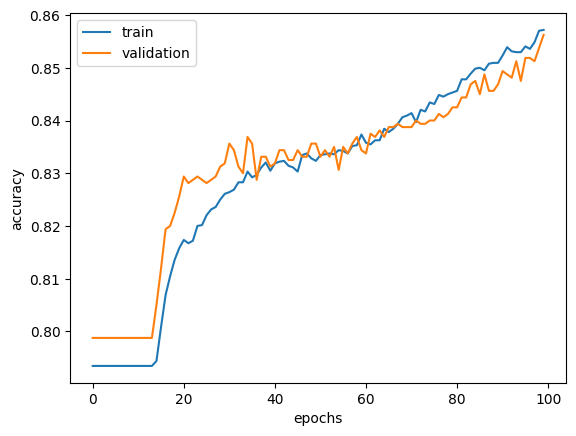

In [ ]:
# plot the accuracy vs val_accuracy
print(model_hist.history.keys())

plt.plot(model_hist.history['accuracy'])
plt.plot(model_hist.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(['train','validation'])
plt.show()

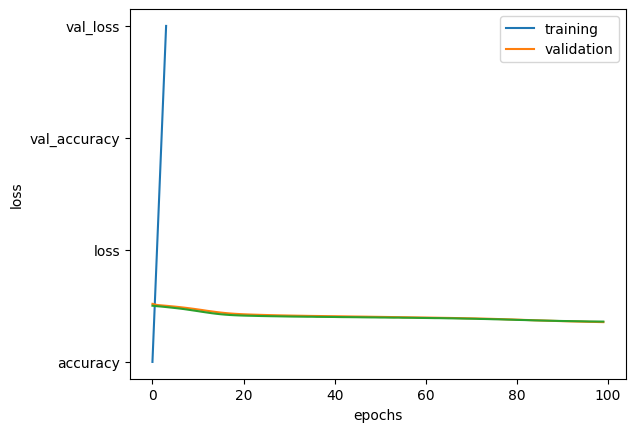

In [ ]:
# plot loss vs val_loss

plt.plot(model_hist.history.keys())

plt.plot(model_hist.history['loss'])
plt.plot(model_hist.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['training','validation'])
plt.show()

In [ ]:
# test prediction
y_pred = model.predict(X_test_scaled)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Classification Report:

               precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.70      0.44      0.54       393

    accuracy                           0.85      2000
   macro avg       0.79      0.70      0.73      2000
weighted avg       0.84      0.85      0.84      2000

testing accuracy: 85.35 %


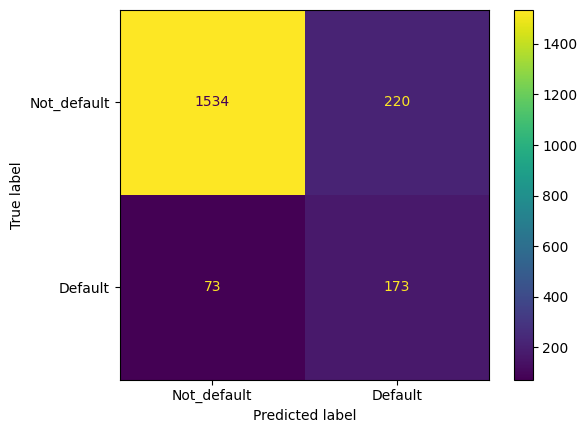

In [ ]:
# validation metrics
# confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
cm = ConfusionMatrixDisplay.from_predictions(y_pred,y_test, display_labels=['Not_de', 'Exited'])

# classification report
print('Classification Report:\n\n', classification_report(y_test,y_pred))

# testing accuracy
print('testing accuracy:', round(accuracy_score(y_test,y_pred)*100,2),'%')